# Cvičení — metriky detekčního systému

Cíl: napsat vlastní implementace tří klíčových metrik:

| Metrika | Co měří | Proč ji chceme |
|---------|---------|----------------|
| **EER** | Threshold-free chybovost | Primární číslo pro srovnání systémů |
| **min-DCF** | Vážená cena chyby | Bere v úvahu cenu false alarm vs. miss |
| **Threshold** | Kde udělat hard decision | Potřeba pro výstupní soubor (0/1) |

Notebook ti ukáže **proč** se ty metriky používají, ne jen jak je spočítat.
Na konci ti zbyde `src/eval/metrics.py` — modul, který budou sdílet všechny experimenty.

---

Buňky s `# TODO` jsou na tebe. Pod každou je validační buňka.
Nepodvádět — validace říká *co* neklape, ne *jak* to opravit. 😄

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

rng = np.random.default_rng(42)

## 1. Co jsou skóre a proč záleží na jejich formátu

Každý náš model produkuje pro každý vzorek jedno číslo — **skóre**.
Čím vyšší, tím víc si model myslí, že jde o target.

### Proč ne jen 0/1?
Pevný práh závisí na podmínkách. Kdybys rekl *"skóre > 0.5 → target"*, 
fungovalo by to jen v jednom konkrétním nastavení. Ale:
- v eval datech může být jiný poměr targetů vs. non-targetů,
- Burget si vybírá práh sám podle **prior = 0.5**.

Se spojitým skóre může kdokoli zvolit libovolný práh a spočítat metriku.

### Proč log-likelihood ratio (LLR)?
```
LLR(x) = log P(x | target) - log P(x | non-target)
```
- LLR = 0 → oba modely souhlasí → prior rozhoduje
- LLR > 0 → target model vysvětluje data lépe
- LLR < 0 → non-target model vysvětluje data lépe

**Pro prior = 0.5: hard decision threshold je přesně 0.** Elegantní.

Taky se skóre z různých systémů dají **jednoduše průměrovat** — to je základ score-level fúze.

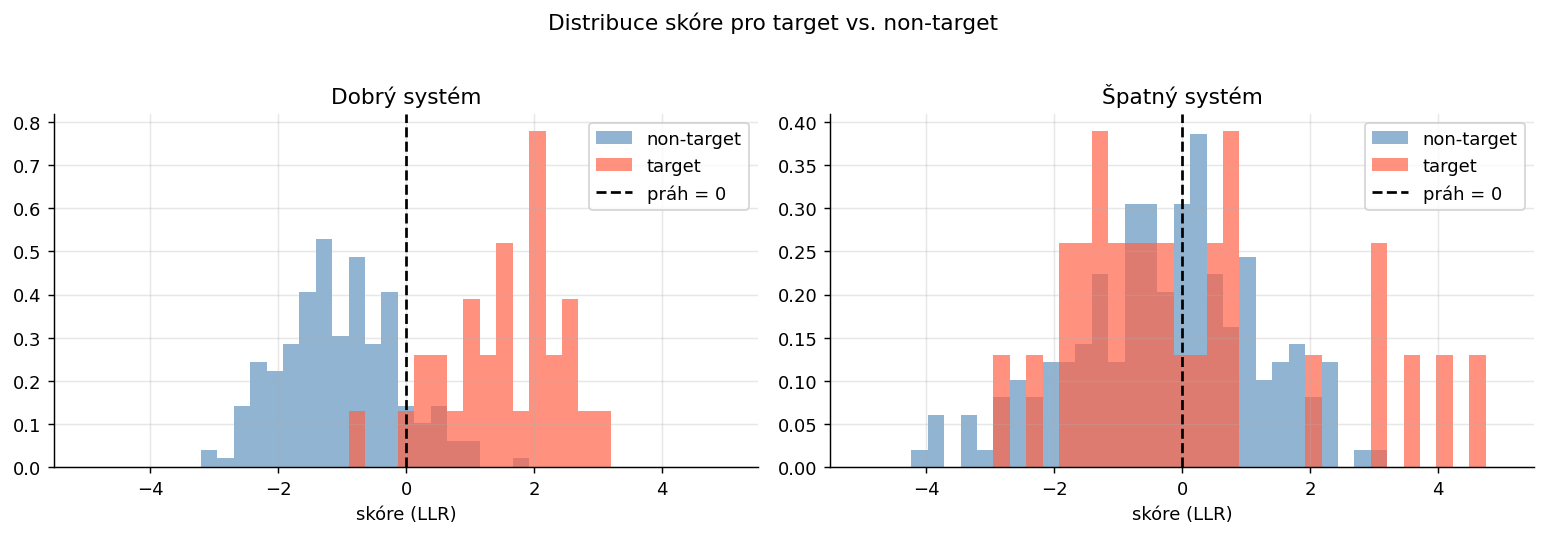

Čím méně se distribuce překrývají, tím lepší systém.


In [2]:
# Simulujeme výstupy hypotetického systému
# V reálu toto budou OOF skóre z našich modelů

N_target = 30
N_nontarget = 192

# Dobrý systém: distribuce se překrývají, ale ne moc
scores_target    = rng.normal(loc=+1.5, scale=1.2, size=N_target)
scores_nontarget = rng.normal(loc=-1.0, scale=1.0, size=N_nontarget)

# Špatný systém: hodně překryvu
scores_target_bad    = rng.normal(loc=+0.3, scale=1.5, size=N_target)
scores_nontarget_bad = rng.normal(loc=-0.3, scale=1.5, size=N_nontarget)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, st, snt, title in zip(
    axes,
    [scores_target, scores_target_bad],
    [scores_nontarget, scores_nontarget_bad],
    ["Dobrý systém", "Špatný systém"],
):
    bins = np.linspace(-5, 5, 40)
    ax.hist(snt, bins=bins, alpha=0.6, color="steelblue", label="non-target", density=True)
    ax.hist(st,  bins=bins, alpha=0.7, color="tomato",    label="target",     density=True)
    ax.axvline(0, color="black", lw=1.5, ls="--", label="práh = 0")
    ax.set_title(title)
    ax.set_xlabel("skóre (LLR)")
    ax.legend()

plt.suptitle("Distribuce skóre pro target vs. non-target", y=1.02)
plt.tight_layout()
plt.show()
print("Čím méně se distribuce překrývají, tím lepší systém.")

## 2. ROC křivka — vizualizace tradeoffů

ROC (Receiver Operating Characteristic) křivka zobrazuje **tradeoff** mezi:
- **TPR** (True Positive Rate) = kolik targetů správně detekujeme = 1 − FRR
- **FPR** (False Positive Rate) = kolik non-targetů špatně pustíme = FAR

Každý bod na křivce odpovídá jinému prahu. Křivka ukazuje, co za co platíme.

**AUC** (Area Under Curve) = 1.0 → perfektní systém, 0.5 → náhoda.

### Terminologie v speaker/face verification:
```
FAR  = False Acceptance Rate  = FPR  (pustíme cizího → bezpečnostní problém)
FRR  = False Rejection Rate   = 1-TPR (odmítneme správného → UX problém)
```

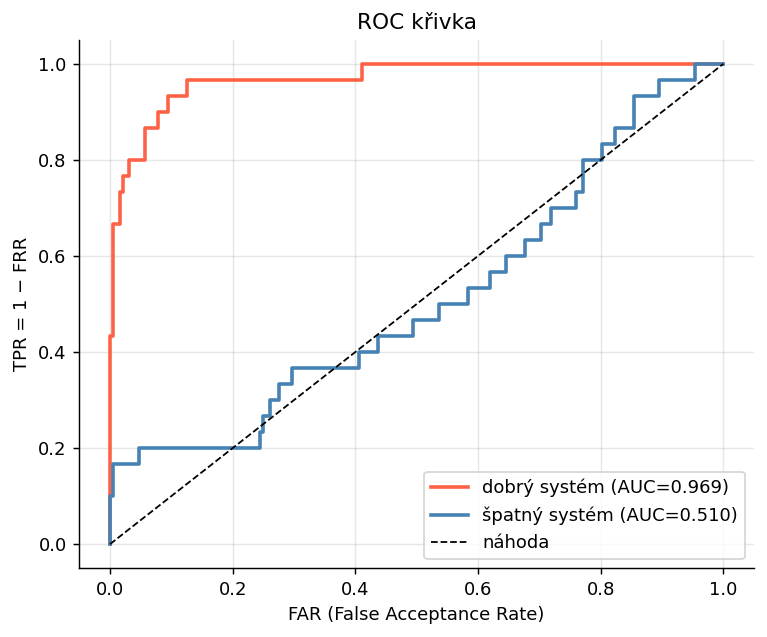

In [3]:
def plot_roc(scores_t, scores_nt, label="systém", ax=None, color="steelblue"):
    y_true  = np.array([1] * len(scores_t) + [0] * len(scores_nt))
    y_score = np.concatenate([scores_t, scores_nt])
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC={roc_auc:.3f})")
    return fpr, tpr, thresholds

fig, ax = plt.subplots(figsize=(6, 5))
plot_roc(scores_target, scores_nontarget,     label="dobrý systém",  ax=ax, color="tomato")
plot_roc(scores_target_bad, scores_nontarget_bad, label="špatný systém", ax=ax, color="steelblue")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="náhoda")
ax.set_xlabel("FAR (False Acceptance Rate)")
ax.set_ylabel("TPR = 1 − FRR")
ax.set_title("ROC křivka")
ax.legend()
plt.tight_layout()
plt.show()

## 3. EER — Equal Error Rate

EER je bod na ROC křivce, kde **FAR = FRR**. 

Proč zrovna tenhle bod?
- Je **threshold-independent** — nezávisí na tom, jaký práh jsme zvolili.
- Je snadno interpretovatelný: *"při optimálním prahu dělám X % chyb v obou směrech"*.
- Umožňuje **srovnání systémů** bez dohody na konkrétním prahu.

EER = 0 % → perfektní systém  
EER = 50 % → náhoda (FAR=FRR=0.5)

### Jak ho spočítat?
1. Pro každý možný práh spočítej FAR a FRR.
2. Najdi práh, kde jsou si nejblíž.
3. Interpoluj přesný průsečík.

```
FRR(θ) = P(score < θ | target)     ← kolik targetů nepustíme
FAR(θ) = P(score ≥ θ | non-target) ← kolik non-targetů pustíme
```

EER = hodnota kde FRR(θ*) = FAR(θ*)

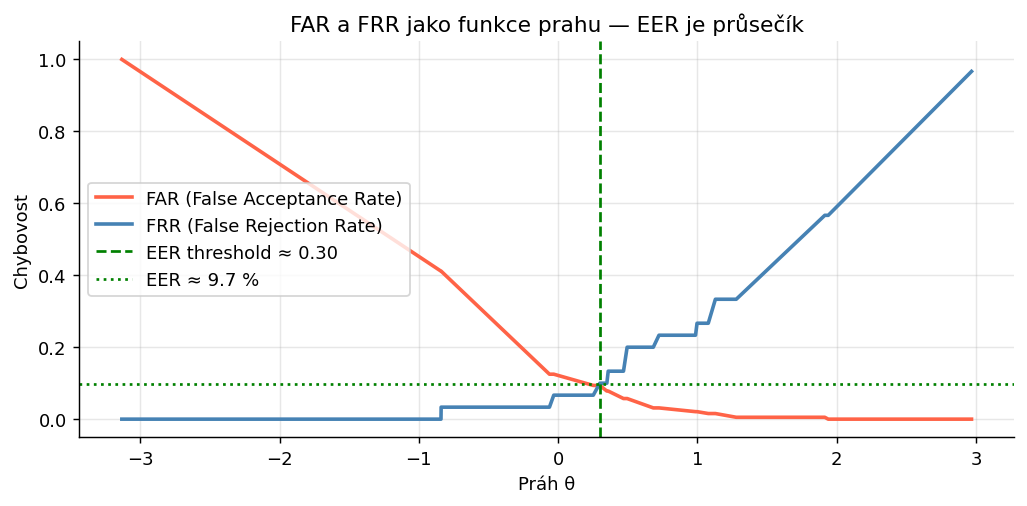

In [4]:
# Vizualizace FAR a FRR jako funkce prahu — pomůže ti pochopit co hledáme

y_true  = np.array([1] * len(scores_target) + [0] * len(scores_nontarget))
y_score = np.concatenate([scores_target, scores_nontarget])

fpr, tpr, thresholds = roc_curve(y_true, y_score)
far = fpr
frr = 1 - tpr

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, far, label="FAR (False Acceptance Rate)", color="tomato",    lw=2)
ax.plot(thresholds, frr, label="FRR (False Rejection Rate)",  color="steelblue", lw=2)

# Najdeme EER vizuálně
idx = np.argmin(np.abs(far - frr))
eer_approx = (far[idx] + frr[idx]) / 2
ax.axvline(thresholds[idx], color="green", ls="--", lw=1.5, label=f"EER threshold ≈ {thresholds[idx]:.2f}")
ax.axhline(eer_approx, color="green", ls=":", lw=1.5, label=f"EER ≈ {eer_approx*100:.1f} %")

ax.set_xlabel("Práh θ")
ax.set_ylabel("Chybovost")
ax.set_title("FAR a FRR jako funkce prahu — EER je průsečík")
ax.legend()
plt.tight_layout()
plt.show()

### ✏️ TODO 1 — implementuj `compute_eer`

Vstup: pole skóre pro target vzorky a pole skóre pro non-target vzorky.  
Výstup: `(eer, threshold)` kde `eer` je EER jako číslo v [0, 1].

**Postup:**
1. Sestav `y_true` a `y_score` (jako nahoře).
2. Použij `sklearn.metrics.roc_curve` — vrátí `fpr, tpr, thresholds`.
3. Přepočítej `frr = 1 - tpr`.
4. Najdi index kde `|far - frr|` je minimální.
5. EER = průměr `far[idx]` a `frr[idx]` (lineární interpolace mezi body).
6. Threshold = `thresholds[idx]`.

In [ ]:
def compute_eer(scores_target: np.ndarray, scores_nontarget: np.ndarray) -> tuple[float, float]:
    """
    Vrať (eer, threshold) kde eer ∈ [0, 1].
    EER = bod kde FAR == FRR (Equal Error Rate).
    """
    # TODO
    return 0.0, 0.0  # <-- nahraď


eer, eer_thresh = compute_eer(scores_target, scores_nontarget)
print(f"EER = {eer*100:.2f} %   (threshold = {eer_thresh:.3f})")

In [ ]:
# --- VALIDATION 1: EER ---
def check_eer(fn):
    problems = []

    # Perfektní systém → EER ≈ 0
    st_perf = np.array([10.0, 8.0, 9.0])
    snt_perf = np.array([-10.0, -8.0, -9.0])
    eer_p, _ = fn(st_perf, snt_perf)
    if eer_p > 0.01:
        problems.append(f"perfektní systém: EER={eer_p:.3f}, očekávám ≈ 0")

    # Náhodný systém → EER ≈ 0.5
    rng2 = np.random.default_rng(99)
    st_rand  = rng2.normal(0, 1, 500)
    snt_rand = rng2.normal(0, 1, 500)
    eer_r, _ = fn(st_rand, snt_rand)
    if not (0.40 < eer_r < 0.60):
        problems.append(f"náhodný systém: EER={eer_r:.3f}, očekávám ~0.5")

    # EER musí být v [0, 1]
    eer_g, _ = fn(scores_target, scores_nontarget)
    if not (0 <= eer_g <= 1):
        problems.append(f"EER mimo rozsah [0,1]: {eer_g}")

    return problems

p = check_eer(compute_eer)
print("✓ OK" if not p else "✗ FAIL:\n  - " + "\n  - ".join(p))

## 4. min-DCF — Detection Cost Function

EER bere obě chyby stejně. Ale co když miss (nepustíme targeta) je horší než false alarm?
DCF nám dovolí nastavit **váhy**.

### Vzorec

```
DCF(θ) = C_miss · P_target · FRR(θ)  +  C_fa · (1 − P_target) · FAR(θ)
```

| Parametr | Bedeutung | Naše hodnoty |
|----------|-----------|--------------|
| `C_miss` | cena miss (nepustit target) | 1.0 |
| `C_fa`   | cena false alarm (pustit cizího) | 1.0 |
| `P_target` | apriorní pravděpodobnost targeta | **0.5** ← Burget explicitně |

Pro naše hodnoty (C_miss=C_fa=1, P_target=0.5):
```
DCF(θ) = 0.5 · FRR(θ) + 0.5 · FAR(θ)
```

### Normalizace
Aby bylo min-DCF srovnatelné napříč systémy, normalizujeme ho baseline cenou —
kdybychom vždy odpovídali "nikdy target" nebo "vždy target":

```
DCF_norm(θ) = DCF(θ) / min(C_miss · P_target, C_fa · (1 − P_target))
            = DCF(θ) / 0.5
```

Takže pro naše podmínky:
```
DCF_norm(θ) = FRR(θ) + FAR(θ)
```

**min-DCF = minimum DCF_norm přes všechny prahy θ.**

Hodnota **≤ 1.0** je lepší než náhodný gues. **min-DCF = 0.0** = perfektní systém.

### Vztah k EER
Při symetrickém nastavení (C_miss=C_fa, P_target=0.5) platí:
- V EER bodě: FRR = FAR = EER_rate → DCF_norm(θ_EER) = 2·EER_rate
- min-DCF ≤ 2·EER (optimum může být jinde než v EER bodě)

Takže **min-DCF je vždy ≤ 2·EER** a říká ti, jestli máš dobře kalibrovaný práh.

In [ ]:
# Vizualizace DCF_norm jako funkce prahu — pomůže ti pochopit co minimalizujeme

y_true  = np.array([1] * len(scores_target) + [0] * len(scores_nontarget))
y_score = np.concatenate([scores_target, scores_nontarget])

fpr, tpr, thresholds = roc_curve(y_true, y_score)
far = fpr
frr = 1 - tpr

P_target = 0.5
C_miss, C_fa = 1.0, 1.0
norm = min(C_miss * P_target, C_fa * (1 - P_target))

dcf = (C_miss * P_target * frr + C_fa * (1 - P_target) * far) / norm

min_idx = np.argmin(dcf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(thresholds, dcf, color="purple", lw=2, label="DCF_norm(θ)")
ax.axvline(thresholds[min_idx], color="green", ls="--", lw=1.5,
           label=f"min-DCF threshold = {thresholds[min_idx]:.2f}")
ax.axhline(dcf[min_idx], color="green", ls=":", lw=1.5,
           label=f"min-DCF = {dcf[min_idx]:.3f}")
ax.set_xlabel("Práh θ")
ax.set_ylabel("DCF_norm")
ax.set_title("DCF jako funkce prahu")
ax.legend()

ax = axes[1]
ax.plot(far, dcf, color="purple", lw=2)
ax.plot(far[min_idx], dcf[min_idx], "go", ms=10, label=f"min-DCF = {dcf[min_idx]:.3f}")
ax.set_xlabel("FAR")
ax.set_ylabel("DCF_norm")
ax.set_title("DCF vs. FAR")
ax.legend()

plt.tight_layout()
plt.show()

### ✏️ TODO 2 — implementuj `compute_min_dcf`

Vstup: skóre, `p_target=0.5`, `c_miss=1.0`, `c_fa=1.0`  
Výstup: `(min_dcf, threshold)` kde `min_dcf` je normalizovaná hodnota.

**Postup:**
1. `roc_curve` → `fpr, tpr, thresholds`
2. `far = fpr`, `frr = 1 - tpr`
3. `dcf = (c_miss * p_target * frr + c_fa * (1-p_target) * far) / norm`
4. `norm = min(c_miss * p_target, c_fa * (1-p_target))`
5. `min_idx = np.argmin(dcf)`
6. Vrať `dcf[min_idx]` a `thresholds[min_idx]`

In [ ]:
def compute_min_dcf(
    scores_target: np.ndarray,
    scores_nontarget: np.ndarray,
    p_target: float = 0.5,
    c_miss: float = 1.0,
    c_fa: float = 1.0,
) -> tuple[float, float]:
    """
    Vrať (min_dcf, threshold).
    min_dcf je normalizovaná DCF — hodnota < 1.0 je lepší než baseline.
    """
    # TODO
    return 0.0, 0.0  # <-- nahraď


min_dcf, dcf_thresh = compute_min_dcf(scores_target, scores_nontarget)
eer, eer_thresh = compute_eer(scores_target, scores_nontarget)
print(f"EER     = {eer*100:.2f} %   (threshold = {eer_thresh:.3f})")
print(f"min-DCF = {min_dcf:.4f}    (threshold = {dcf_thresh:.3f})")
print(f"Očekávám min-DCF ≤ 2·EER = {2*eer:.4f}")

In [ ]:
# --- VALIDATION 2: min-DCF ---
def check_min_dcf(fn):
    problems = []

    # Perfektní systém → min-DCF ≈ 0
    st_perf  = np.array([10.0, 8.0, 9.0])
    snt_perf = np.array([-10.0, -8.0, -9.0])
    dcf_p, _ = fn(st_perf, snt_perf)
    if dcf_p > 0.01:
        problems.append(f"perfektní systém: min-DCF={dcf_p:.4f}, očekávám ≈ 0")

    # Náhodný systém → min-DCF ≈ 1.0
    rng2 = np.random.default_rng(99)
    st_rand  = rng2.normal(0, 1, 500)
    snt_rand = rng2.normal(0, 1, 500)
    dcf_r, _ = fn(st_rand, snt_rand)
    if not (0.80 < dcf_r < 1.05):  # může být lehce nad 1 kvůli diskretizaci
        problems.append(f"náhodný systém: min-DCF={dcf_r:.4f}, očekávám ~1.0")

    # min-DCF ≤ 2 · EER
    from sklearn.metrics import roc_curve
    eer_val, _ = compute_eer(scores_target, scores_nontarget)
    dcf_val, _ = fn(scores_target, scores_nontarget)
    if dcf_val > 2 * eer_val + 0.01:
        problems.append(f"min-DCF={dcf_val:.4f} > 2·EER={2*eer_val:.4f}")

    return problems

p = check_min_dcf(compute_min_dcf)
print("✓ OK" if not p else "✗ FAIL:\n  - " + "\n  - ".join(p))

## 5. Threshold pro hard decision

Burget chce ve výstupním souboru jak skóre, tak `0/1`. Jak vybrat práh?

### Bayesovský pohled
Při prior = 0.5 (C_miss = C_fa = 1) je optimální práh tam, kde:
```
P(target | x) = P(non-target | x)
```
Což v log-likelihood ratio prostoru znamená přesně **LLR = 0**.

Takže: **pokud máš dobře kalibrovaná LLR skóre, threshold = 0.**

Ale v praxi:
- Skóre z GMM nebo logistické regrese **nemusí být správně kalibrovaná**.
- Proto: kalibruj OOF skóre → pak práh = 0 bude správně.

Alternativa (bez kalibrace):
- Vyber práh, který minimalizuje DCF na OOF skóre.
- `compute_min_dcf` už ti threshold vrací — to je přesně ten práh!

### ✏️ TODO 3 — implementuj `make_hard_decisions`

In [ ]:
def make_hard_decisions(scores: np.ndarray, threshold: float) -> np.ndarray:
    """
    Vrať pole 0/1: 1 pokud score >= threshold, jinak 0.
    """
    # TODO — one-liner
    return np.zeros(len(scores), dtype=int)  # <-- nahraď


# Test
test_scores = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
decisions = make_hard_decisions(test_scores, threshold=0.0)
print("skóre:    ", test_scores)
print("decision: ", decisions)
print("(očekávám: [0 0 1 1 1])")

In [ ]:
# --- VALIDATION 3: hard decisions ---
def check_decisions(fn):
    problems = []
    s = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
    d = fn(s, threshold=0.0)
    expected = np.array([0, 0, 1, 1, 1])
    if not np.array_equal(d, expected):
        problems.append(f"threshold=0: dostal jsem {d}, očekávám {expected}")
    if d.dtype not in [np.int32, np.int64, int]:
        problems.append(f"dtype musí být int, je {d.dtype}")
    d2 = fn(s, threshold=-0.5)
    if d2[1] != 1:  # -0.5 >= -0.5 → True
        problems.append("threshold=-0.5: -0.5 >= -0.5 by mělo být 1")
    return problems

p = check_decisions(make_hard_decisions)
print("✓ OK" if not p else "✗ FAIL:\n  - " + "\n  - ".join(p))

## 6. OOF (Out-Of-Fold) skóre — zlatý standard pro evaluaci

Když trénujeme K modelů (jeden per fold), každý vzorek byl jednou v **validation setu**.
Tehdy mu byl přiřazeno skóre modelem, který ho **nikdy neviděl v trainu** → **unbiased odhad**.

```
fold 0: train [1,2,3,...] → val [0] → score_oof[0] = model_0.score(X[0])
fold 1: train [0,2,3,...] → val [1] → score_oof[1] = model_1.score(X[1])
...
```

Na konci máš `score_oof` délky N (celý dataset) — každý vzorek přesně jednou, vždy ohodnocený blind modelem.

### K čemu OOF skóre slouží:
1. **Evaluace** — EER a min-DCF na OOF jsou poctivé číslo
2. **Kalibrace** — Platt/isotonic fittujeme na OOF, ne na train
3. **Fusion** — OOF skóre z audio + image → vstup do fusion modelu
4. **Threshold selection** — najdi práh na OOF, použij na eval datech

### ✏️ TODO 4 — implementuj `collect_oof_scores`

In [ ]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("../src").resolve()))
from data.splits import load_manifest, iter_folds_loso

manifest = load_manifest(Path("../data"))


def collect_oof_scores(df, model_fn, feature_fn, n_splits=3, seed=67):
    """
    Projdi všechny foldy a sbírej OOF skóre.

    Args:
        df         — manifest DataFrame
        model_fn   — callable(X_train, y_train) → model s metodou .score_samples(X) nebo .predict_proba(X)
        feature_fn — callable(df_subset) → np.ndarray shape (N, D)
        n_splits   — počet foldů

    Vrací:
        oof_scores — np.ndarray délky len(df), OOF skóre pro každý vzorek
    """
    oof_scores = np.full(len(df), np.nan)

    # TODO:
    # 1. for fold_id, train_idx, val_idx in iter_folds_loso(df):
    # 2.   X_train = feature_fn(df.loc[train_idx])
    # 3.   y_train = df.loc[train_idx, "label"].to_numpy()
    # 4.   model = model_fn(X_train, y_train)
    # 5.   X_val = feature_fn(df.loc[val_idx])
    # 6.   oof_scores[val_idx] = model.predict_log_proba(X_val)[:, 1] nebo podobně

    return oof_scores


print("collect_oof_scores definována — otestujeme ji až budeme mít první model")

## 7. Vizuální souhrn — Det křivka (DET curve)

DET křivka je jako ROC, ale osy jsou na normálním probit scale — typická pro speaker verification.
Na probit scale vypadá ideální systém jako přímka, takže odchylky od ideálu jsou viditelnější.

In [ ]:
from scipy.stats import norm as scipy_norm

def plot_det(scores_t, scores_nt, label="systém", ax=None, color="steelblue"):
    y_true  = np.array([1]*len(scores_t) + [0]*len(scores_nt))
    y_score = np.concatenate([scores_t, scores_nt])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    far = np.clip(fpr, 1e-4, 1 - 1e-4)
    frr = np.clip(1 - tpr, 1e-4, 1 - 1e-4)
    eer, _ = compute_eer(scores_t, scores_nt)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(scipy_norm.ppf(far), scipy_norm.ppf(frr),
            color=color, lw=2, label=f"{label} (EER={eer*100:.1f}%)")
    return ax

ticks = [0.001, 0.01, 0.05, 0.1, 0.2, 0.4]
tick_labels = [f"{t*100:.1f}" for t in ticks]
tick_pos = [scipy_norm.ppf(t) for t in ticks]

fig, ax = plt.subplots(figsize=(6, 6))
plot_det(scores_target, scores_nontarget,         label="dobrý systém",  ax=ax, color="tomato")
plot_det(scores_target_bad, scores_nontarget_bad, label="špatný systém", ax=ax, color="steelblue")
ax.plot(tick_pos, tick_pos, "k--", lw=1, label="EER linie")
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET křivka (probit scale)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hotovo → převedeme do `src/eval/metrics.py`

Jakmile ti všechny validace vracejí `✓ OK`, dej vědět.
Zkopírujeme `compute_eer`, `compute_min_dcf`, `make_hard_decisions` do produkčního modulu.

API které pak budeme používat v každém experimentu:

```python
from src.eval.metrics import compute_eer, compute_min_dcf, make_hard_decisions

eer, _       = compute_eer(oof_scores[y==1], oof_scores[y==0])
min_dcf, thr = compute_min_dcf(oof_scores[y==1], oof_scores[y==0])
decisions    = make_hard_decisions(eval_scores, threshold=thr)

print(f"EER = {eer*100:.2f}%, min-DCF = {min_dcf:.4f}")
```